# 06 — Rule Coverage Analysis & Unknown Word (OOV) Analysis

This notebook investigates **two key aspects** of our rule-based POS tagger:

1. **Rule Coverage Analysis** — Which rule in the cascade handles each token?  
   How much of the tagging work is done by the lexicon vs. morphology vs. context rules?
2. **Unknown Word (OOV) Analysis** — How many test/dev tokens are *out-of-vocabulary*  
   (not seen during training)? What POS tags do they tend to carry? How well does the  
   tagger perform on OOV tokens compared to known tokens?

In [29]:
import sys, os, warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.use("module://matplotlib_inline.backend_inline")

# Add project root to path so we can import src modules
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"

## 1  Load data & build tagger

In [30]:
from src.parser import parse_conllu, get_forms_and_tags
from src.lexicon import Lexicon
from src.tagger import RuleBasedTagger
from src.rules import (
    punct_num_rule,
    closed_class_rule,
    capitalization_rule,
    morphology_rule,
    context_rule,
)

# Parse data
train_sents = parse_conllu(DATA_DIR / "en_ewt-ud-train.conllu")
dev_sents   = parse_conllu(DATA_DIR / "en_ewt-ud-dev.conllu")
test_sents  = parse_conllu(DATA_DIR / "en_ewt-ud-test.conllu")

# Build lexicon from training data
lexicon = Lexicon().build(train_sents)

# Build tagger
tagger = RuleBasedTagger(lexicon, use_innovation=False)

print(f"Lexicon: {lexicon}")
print(f"Train: {len(train_sents):,} sentences")
print(f"Dev:   {len(dev_sents):,} sentences")
print(f"Test:  {len(test_sents):,} sentences")

Lexicon: Lexicon(vocab=16,654, tokens=204,577, tags=17)
Train: 12,544 sentences
Dev:   2,001 sentences
Test:  2,077 sentences


# Rule Coverage Analysis

We trace through the tagger's cascade and record **which rule** assigns a tag to each token.

In [31]:
def trace_rule_coverage(tagger, sentences):
    """
    For each token in the corpus, determine which rule in the cascade
    assigned its tag.
    
    Returns a list of dicts with keys:
      word, gold_tag, pred_tag, rule_name
    """
    results = []
    ft = get_forms_and_tags(sentences)
    
    for words, gold_tags in ft:
        n = len(words)
        tags = [None] * n
        rule_names = [None] * n
        
        # Pass 1: punct/num, closed-class
        for i, w in enumerate(words):
            tag = punct_num_rule(w)
            if tag:
                tags[i] = tag
                rule_names[i] = "punct_num"
                continue
            tag = closed_class_rule(w)
            if tag:
                tags[i] = tag
                rule_names[i] = "closed_class"
                continue
        
        # Pass 2: lexicon, capitalization, morphology
        for i, w in enumerate(words):
            if tags[i] is not None:
                continue
            tag = tagger.lexicon.lookup(w)
            if tag:
                tags[i] = tag
                rule_names[i] = "lexicon"
                continue
            tag = capitalization_rule(w, position=i)
            if tag:
                tags[i] = tag
                rule_names[i] = "capitalization"
                continue
            tag = morphology_rule(w)
            if tag:
                tags[i] = tag
                rule_names[i] = "morphology"
                continue
        
        # Pass 3: context rules + default
        for i, w in enumerate(words):
            if tags[i] is not None:
                continue
            ctx = list(tags)
            ctx[i] = None
            tag = context_rule(w, ctx)
            if tag:
                tags[i] = tag
                rule_names[i] = "context"
                continue
            tags[i] = "NOUN"  # default
            rule_names[i] = "default"
        
        for i in range(n):
            results.append({
                "word": words[i],
                "gold_tag": gold_tags[i],
                "pred_tag": tags[i],
                "rule_name": rule_names[i],
            })
    
    return results

In [32]:
# Trace on DEV set
dev_trace = trace_rule_coverage(tagger, dev_sents)
dev_trace_df = pd.DataFrame(dev_trace)

print(f"Total tokens (dev): {len(dev_trace_df):,}")
dev_trace_df.head(10)

Total tokens (dev): 25,147


,word,gold_tag,pred_tag,rule_name
0,From,ADP,ADP,lexicon
1,the,DET,DET,closed_class
2,AP,PROPN,NOUN,lexicon
3,comes,VERB,VERB,lexicon
4,this,DET,DET,lexicon
5,story,NOUN,NOUN,lexicon
6,:,PUNCT,PUNCT,punct_num
7,President,PROPN,PROPN,lexicon
8,Bush,PROPN,PROPN,lexicon
9,on,ADP,ADP,lexicon


### 1.1  Rule usage distribution

In [33]:
rule_counts = dev_trace_df["rule_name"].value_counts()
rule_pct = (rule_counts / len(dev_trace_df) * 100).round(2)

rule_summary = pd.DataFrame({
    "Rule": rule_counts.index,
    "Tokens": rule_counts.values,
    "Pct (%)": rule_pct.values,
}).reset_index(drop=True)

rule_summary

,Rule,Tokens,Pct (%)
0,lexicon,15165,60.31
1,closed_class,4856,19.31
2,punct_num,3503,13.93
3,capitalization,587,2.33
4,default,503,2.00
5,morphology,267,1.06
6,context,266,1.06


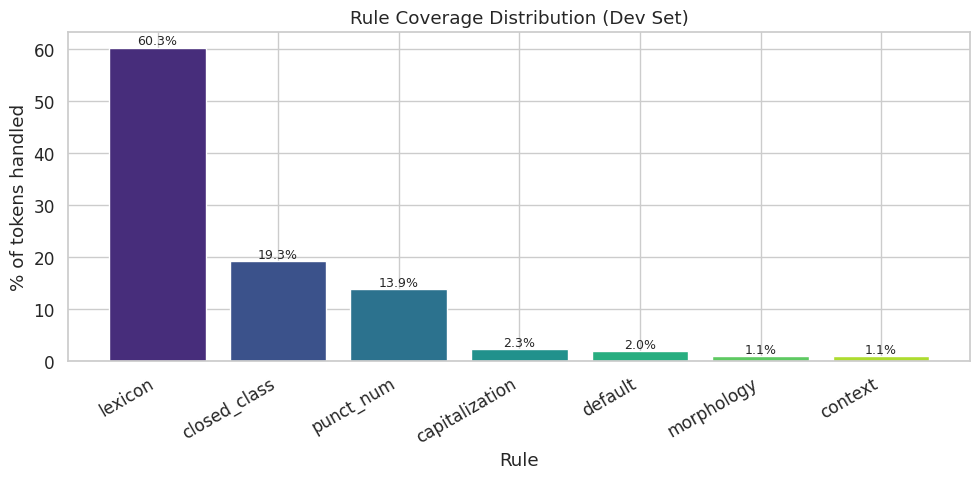

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("viridis", n_colors=len(rule_summary))
ax.bar(rule_summary["Rule"], rule_summary["Pct (%)"], color=colors)
ax.set_xlabel("Rule")
ax.set_ylabel("% of tokens handled")
ax.set_title("Rule Coverage Distribution (Dev Set)")
for i, row in rule_summary.iterrows():
    ax.text(i, row["Pct (%)"] + 0.5, f"{row['Pct (%)']:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('../outputs/Rule_Coverage_Distribution.png', dpi=150)
plt.show()

### 1.2  Per-rule accuracy

In [35]:
dev_trace_df["correct"] = dev_trace_df["gold_tag"] == dev_trace_df["pred_tag"]

per_rule_acc = dev_trace_df.groupby("rule_name").agg(
    tokens=("correct", "count"),
    correct=("correct", "sum"),
).reset_index()
per_rule_acc["accuracy"] = (per_rule_acc["correct"] / per_rule_acc["tokens"] * 100).round(2)

per_rule_acc.sort_values("accuracy", ascending=False)

,rule_name,tokens,correct,accuracy
6,punct_num,3503,3367,96.12
4,lexicon,15165,13321,87.84
1,closed_class,4856,4248,87.48
0,capitalization,587,464,79.05
5,morphology,267,199,74.53
2,context,266,150,56.39
3,default,503,184,36.58


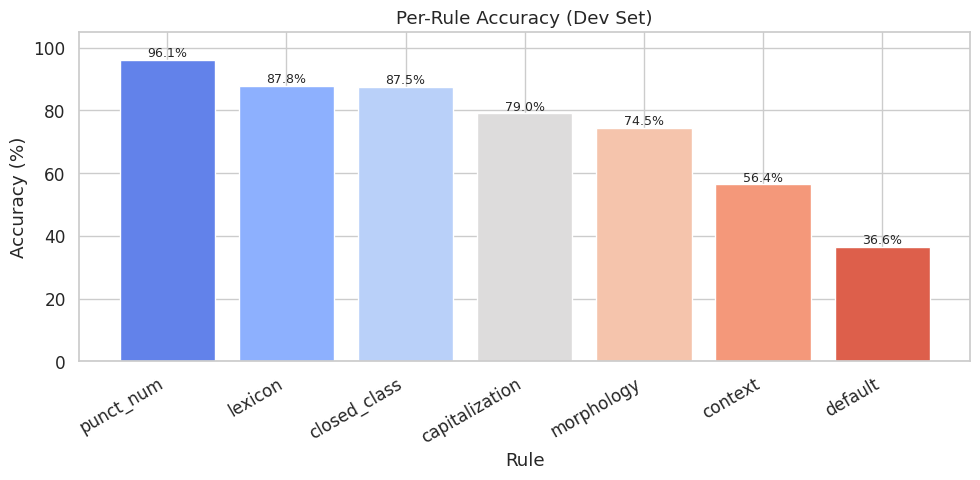

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("coolwarm", n_colors=len(per_rule_acc))
sorted_acc = per_rule_acc.sort_values("accuracy", ascending=False)
ax.bar(sorted_acc["rule_name"], sorted_acc["accuracy"], color=colors)
ax.set_xlabel("Rule")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Rule Accuracy (Dev Set)")
ax.set_ylim(0, 105)
for i, row in sorted_acc.reset_index(drop=True).iterrows():
    ax.text(i, row["accuracy"] + 1, f"{row['accuracy']:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('../outputs/Per_Rule_Accuracy.png', dpi=150)
plt.show()


#  Unknown Word (OOV) Analysis

Out-of-Vocabulary (OOV) words are tokens in the dev/test sets that were **not seen** in the training data.

### 2.1  Lexicon coverage across splits

In [37]:
train_cov = lexicon.coverage(train_sents)
dev_cov = lexicon.coverage(dev_sents)
test_cov = lexicon.coverage(test_sents)

cov_df = pd.DataFrame([
    {"Split": "train", "Known": train_cov[0], "Total": train_cov[1], "Coverage (%)": round(train_cov[2], 2)},
    {"Split": "dev",   "Known": dev_cov[0],   "Total": dev_cov[1],   "Coverage (%)": round(dev_cov[2], 2)},
    {"Split": "test",  "Known": test_cov[0],  "Total": test_cov[1],  "Coverage (%)": round(test_cov[2], 2)},
])
cov_df["OOV"] = cov_df["Total"] - cov_df["Known"]
cov_df["OOV (%)"] = ((cov_df["OOV"] / cov_df["Total"]) * 100).round(2)

cov_df

,Split,Known,Total,Coverage (%),OOV,OOV (%)
0,train,204577,204577,100.0,0,0.0
1,dev,23438,25147,93.2,1709,6.8
2,test,23212,25094,92.5,1882,7.5


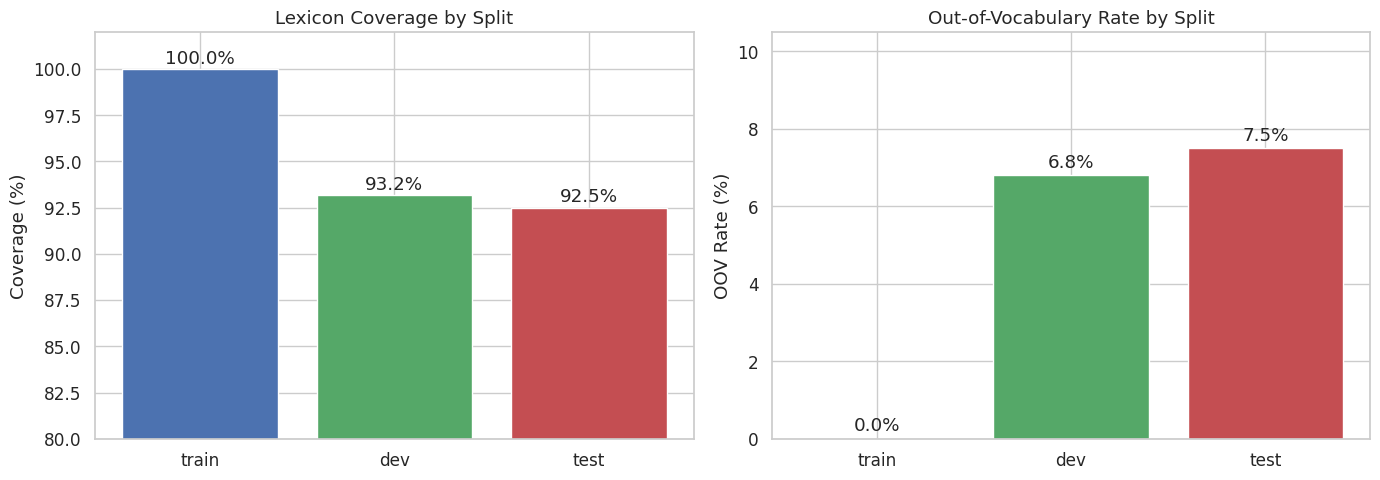

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot: coverage
colors = ["#4C72B0", "#55A868", "#C44E52"]
axes[0].bar(cov_df["Split"], cov_df["Coverage (%)"], color=colors)
axes[0].set_ylabel("Coverage (%)")
axes[0].set_title("Lexicon Coverage by Split")
axes[0].set_ylim(80, 102)
for i, row in cov_df.iterrows():
    axes[0].text(i, row["Coverage (%)"] + 0.3, f"{row['Coverage (%)']:.1f}%", ha="center")

# Bar plot: OOV rate
axes[1].bar(cov_df["Split"], cov_df["OOV (%)"], color=colors)
axes[1].set_ylabel("OOV Rate (%)")
axes[1].set_title("Out-of-Vocabulary Rate by Split")
axes[1].set_ylim(0, max(cov_df["OOV (%)"]) + 3)
for i, row in cov_df.iterrows():
    axes[1].text(i, row["OOV (%)"] + 0.2, f"{row['OOV (%)']:.1f}%", ha="center")

plt.tight_layout()
plt.savefig('../outputs/Lexicon_coverage.png', dpi=150)
plt.show()

### 2.2  POS tag distribution for OOV words

In [39]:
# Identify OOV tokens in the dev set
oov_tags = []
known_tags = []
for sent in dev_sents:
    for tok in sent:
        if tok.form.lower() in lexicon.word_tag:
            known_tags.append(tok.upos)
        else:
            oov_tags.append(tok.upos)

oov_counter = Counter(oov_tags)
known_counter = Counter(known_tags)

oov_tag_df = pd.DataFrame(
    oov_counter.most_common(), columns=["UPOS", "OOV Count"]
)
oov_tag_df["OOV Pct (%)"] = (oov_tag_df["OOV Count"] / sum(oov_counter.values()) * 100).round(2)

oov_tag_df

,UPOS,OOV Count,OOV Pct (%)
0,PROPN,685,40.08
1,NOUN,507,29.67
2,VERB,164,9.60
3,ADJ,128,7.49
4,NUM,108,6.32
5,ADV,29,1.70
6,PUNCT,24,1.40
7,X,22,1.29
8,INTJ,17,0.99
9,SYM,9,0.53


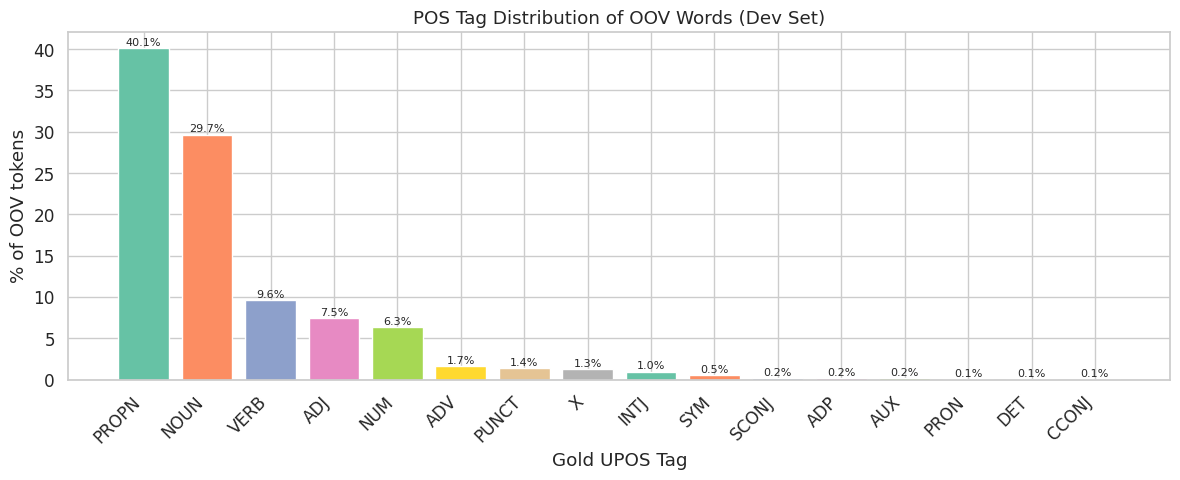

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("Set2", n_colors=len(oov_tag_df))
ax.bar(oov_tag_df["UPOS"], oov_tag_df["OOV Pct (%)"], color=colors)
ax.set_xlabel("Gold UPOS Tag")
ax.set_ylabel("% of OOV tokens")
ax.set_title("POS Tag Distribution of OOV Words (Dev Set)")
for i, row in oov_tag_df.iterrows():
    ax.text(i, row["OOV Pct (%)"] + 0.3, f"{row['OOV Pct (%)']:.1f}%", ha="center", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('../outputs/POS_Tag_distribution_of_OOV_Words.png', dpi=150)
plt.show()

### 2.3  Accuracy: Known vs OOV words

In [41]:
# Use the dev trace to split accuracy by known/OOV
dev_trace_df["is_oov"] = dev_trace_df["word"].apply(
    lambda w: w.lower() not in lexicon.word_tag
)

acc_by_oov = dev_trace_df.groupby("is_oov").agg(
    tokens=("correct", "count"),
    correct=("correct", "sum"),
).reset_index()
acc_by_oov["accuracy (%)"] = (acc_by_oov["correct"] / acc_by_oov["tokens"] * 100).round(2)
acc_by_oov["category"] = acc_by_oov["is_oov"].map({True: "OOV", False: "Known"})

acc_by_oov[["category", "tokens", "correct", "accuracy (%)"]]

,category,tokens,correct,accuracy (%)
0,Known,23438,20867,89.03
1,OOV,1709,1066,62.38


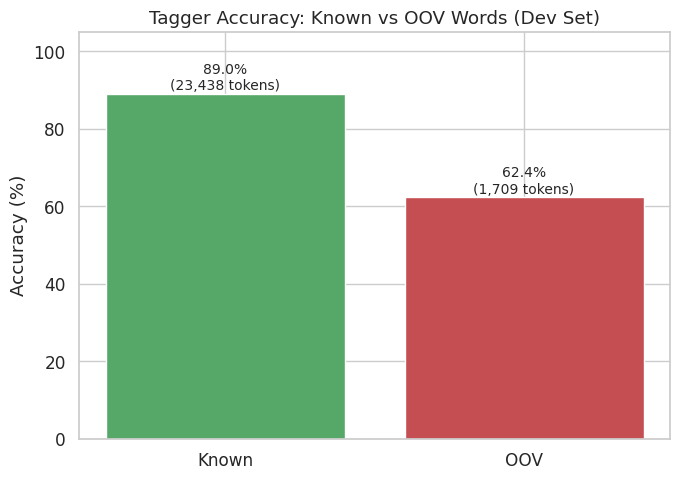

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#55A868", "#C44E52"]
ax.bar(acc_by_oov["category"], acc_by_oov["accuracy (%)"], color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Tagger Accuracy: Known vs OOV Words (Dev Set)")
ax.set_ylim(0, 105)
for i, row in acc_by_oov.iterrows():
    ax.text(i, row["accuracy (%)"] + 1,
            f"{row['accuracy (%)']:.1f}%\n({row['tokens']:,} tokens)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/Tagger_accuracy.png', dpi=150)
plt.show()

### 2.4  Most frequent OOV words & their tagging results

In [43]:
oov_df = dev_trace_df[dev_trace_df["is_oov"]].copy()

oov_word_stats = oov_df.groupby("word").agg(
    count=("word", "count"),
    gold_tags=("gold_tag", lambda x: ", ".join(sorted(set(x)))),
    pred_tags=("pred_tag", lambda x: ", ".join(sorted(set(x)))),
    correct=("correct", "sum"),
    rule=("rule_name", lambda x: ", ".join(sorted(set(x)))),
).reset_index()
oov_word_stats["accuracy (%)"] = (oov_word_stats["correct"] / oov_word_stats["count"] * 100).round(1)

# Top 20 most frequent OOV words
oov_word_stats.sort_values("count", ascending=False).head(20)

,word,count,gold_tags,pred_tags,correct,rule,accuracy (%)
240,Debra,19,PROPN,"NOUN, PROPN",1,"capitalization, default",5.3
471,Perlingiere,18,PROPN,PROPN,18,capitalization,100.0
417,Miramar,14,PROPN,"NOUN, PROPN",11,"capitalization, default",78.6
139,Abbas,10,PROPN,"NOUN, PROPN",8,"capitalization, default",80.0
275,Firefox,9,PROPN,PROPN,9,capitalization,100.0
422,Mozilla,8,PROPN,PROPN,8,capitalization,100.0
445,Noida,7,PROPN,PROPN,7,capitalization,100.0
570,Traci,6,PROPN,NOUN,0,default,0.0
281,GISB,6,"NOUN, X",PROPN,0,capitalization,0.0
307,HANO,6,PROPN,PROPN,6,capitalization,100.0


### 2.5  Rule usage for OOV words

In [44]:
oov_rule_counts = oov_df["rule_name"].value_counts()
oov_rule_pct = (oov_rule_counts / len(oov_df) * 100).round(2)

oov_rule_summary = pd.DataFrame({
    "Rule": oov_rule_counts.index,
    "OOV Tokens": oov_rule_counts.values,
    "Pct (%)": oov_rule_pct.values,
}).reset_index(drop=True)

oov_rule_summary

,Rule,OOV Tokens,Pct (%)
0,capitalization,587,34.35
1,default,503,29.43
2,morphology,267,15.62
3,context,266,15.56
4,punct_num,86,5.03


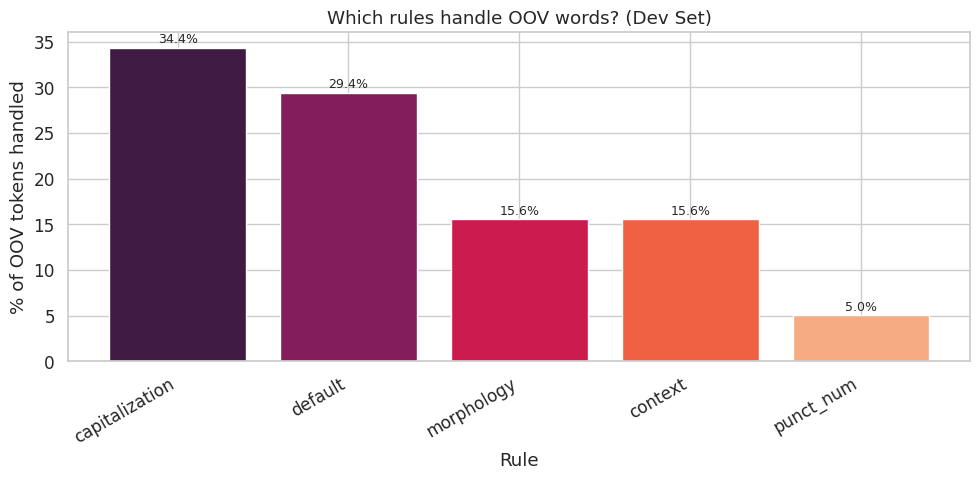

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("rocket", n_colors=len(oov_rule_summary))
ax.bar(oov_rule_summary["Rule"], oov_rule_summary["Pct (%)"], color=colors)
ax.set_xlabel("Rule")
ax.set_ylabel("% of OOV tokens handled")
ax.set_title("Which rules handle OOV words? (Dev Set)")
for i, row in oov_rule_summary.iterrows():
    ax.text(i, row["Pct (%)"] + 0.5, f"{row['Pct (%)']:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('../outputs/rules_handling_oov.png', dpi=150)
plt.show()

### 2.6  Suffix patterns of OOV words

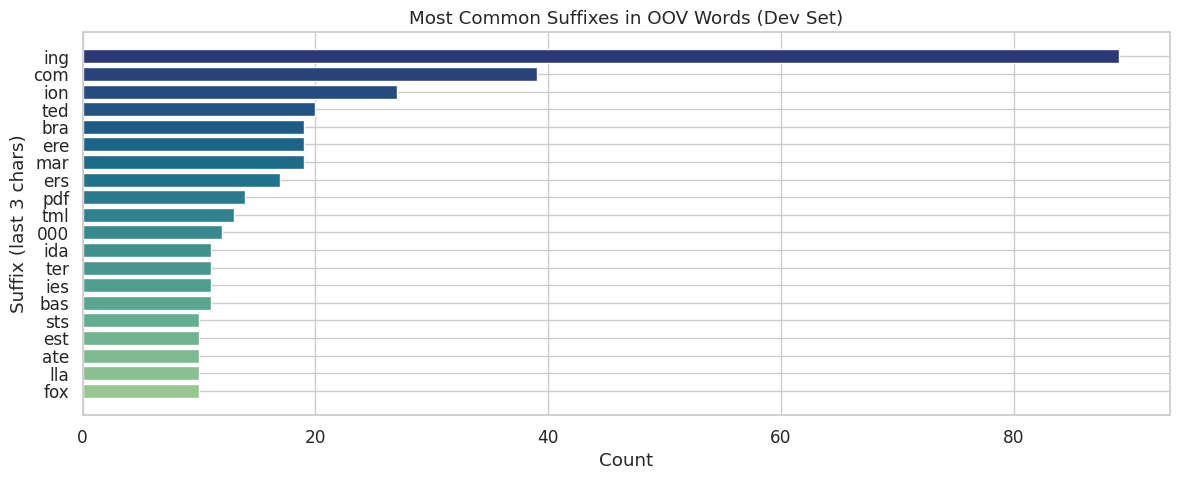

In [46]:
# Collect the last 3 characters of each OOV word
oov_suffixes = oov_df[oov_df["word"].str.len() >= 4]["word"].apply(
    lambda w: w[-3:].lower()
)
suffix_counter = Counter(oov_suffixes)
suffix_df = pd.DataFrame(suffix_counter.most_common(20), columns=["Suffix", "Count"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(suffix_df["Suffix"][::-1], suffix_df["Count"][::-1],
        color=sns.color_palette("crest", n_colors=20))
ax.set_xlabel("Count")
ax.set_ylabel("Suffix (last 3 chars)")
ax.set_title("Most Common Suffixes in OOV Words (Dev Set)")
plt.tight_layout()
plt.savefig('../outputs/common_suffixes_in_OOV_words.png', dpi=150)
plt.show()

## Key Takeaways

1. **Lexicon dominates**: The majority of tokens are tagged via the lexicon lookup rule, which confirms the importance of a high-quality training lexicon.

2. **OOV rate**: The dev/test OOV rate shows how many tokens the tagger has never seen during training. These tokens must rely on morphology, capitalization, context, or default rules.

3. **Accuracy gap**: Known words are tagged with much higher accuracy than OOV words, highlighting the challenge of handling unseen vocabulary.

4. **OOV POS distribution**: OOV words are predominantly NOUNs and PROPNs, which makes sense — proper nouns and domain-specific nouns are the most likely tokens to be unseen.

5. **Suffix patterns**: Common suffixes like *-ing*, *-tion*, *-ous* can help the morphology rule correctly tag many OOV words. Improving suffix rule coverage could significantly boost OOV accuracy.